# 03 Alert triage: detector alone vs the agent pipeline

Production surveillance tunes its first stage toward recall and accepts false alerts, because a missed episode is costlier than reviewer time. This notebook measures that trade: a loosened alerting configuration (`DetectionConfig.alerting()`) over-alerts on purpose, and the case graph's verification step prunes the alerts that do not survive the canonical thresholds.

**What is replayed here.** The Pattern Detector agent's verification rule is deterministic (recompute the statistics with the canonical detection functions and compare against canonical thresholds), so `evaluation.replay` applies it without a model. These numbers measure the pipeline's decision rule; memo prose quality is a separate, model-dependent question.

In [1]:
import json, sys
sys.path.insert(0, "../src")
import pandas as pd
from datagen.config import GeneratorConfig
from detection.config import DetectionConfig
from detection.detectors import run_detection
from detection.matching import label_hits
from evaluation.harness import detection_metrics, triage_metrics
from evaluation.replay import replay_triage
from schemas.events import GroundTruthEpisode

events = pd.read_parquet("../eval/dataset/events.parquet")
episodes = [GroundTruthEpisode(**e) for e in json.load(open("../eval/dataset/ground_truth.json"))]
ticks = {s.symbol: s.tick_size for s in GeneratorConfig.full().instruments}

alerts = run_detection(events, ticks, DetectionConfig.alerting())
before = detection_metrics(alerts, episodes, events)
print("alerting stage:", len(alerts), "alerts")
print("  hit precision:", before["hit_precision"])
print("  family recall:", before["family_recall"])

alerting stage: 146 alerts
  hit precision: 0.973 (142/146, 95% CI 0.932-0.989)
  family recall: 1.000 (42/42, 95% CI 0.916-1.000)


In [2]:
_, labeled = label_hits(alerts, episodes)
rec = replay_triage(labeled, events, ticks)
after = triage_metrics(labeled, episodes, rec, events)
print("after triage:", after["n_escalated"], "escalations from", after["n_alerts_in"], "alerts")
print("  escalation precision:", after["escalation_precision"])
print("  episode recall:      ", after["episode_recall_after_triage"])
print("  FPR:                 ", after["false_positive_rate_after_triage"])

after triage: 141 escalations from 146 alerts
  escalation precision: 1.000 (141/141, 95% CI 0.973-1.000)
  episode recall:       1.000 (42/42, 95% CI 0.916-1.000)
  FPR:                  0.000 (0/59098, 95% CI 0.000-0.000)


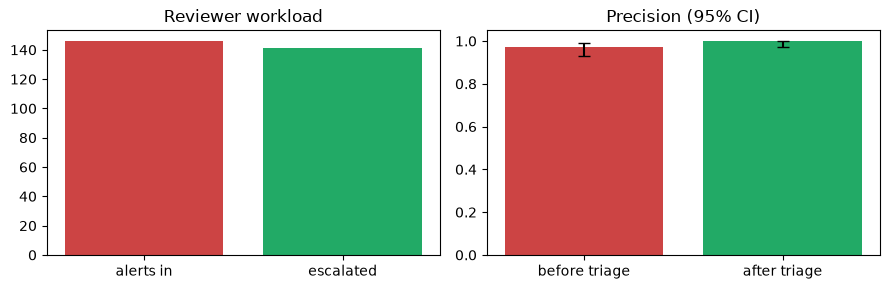

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(["alerts in", "escalated"], [after["n_alerts_in"], after["n_escalated"]],
            color=["#c44", "#2a6"])
axes[0].set_title("Reviewer workload")
pb, pa = before["hit_precision"], after["escalation_precision"]
axes[1].bar(["before triage", "after triage"], [pb.value, pa.value],
            yerr=[[pb.value - pb.ci_low, pa.value - pa.ci_low],
                  [pb.ci_high - pb.value, pa.ci_high - pa.value]],
            color=["#c44", "#2a6"], capsize=4)
axes[1].set_ylim(0, 1.05); axes[1].set_title("Precision (95% CI)")
plt.tight_layout()

The pipeline's value in this setup is precision at held recall: triage removes the false alerts the loose first stage admits while keeping every injected episode. The single-stage alternative forces a choice between the two configurations; the two-stage design gets the recall of the loose one and the precision of the strict one, at the cost of running the case graph per alert.